### **Richter's Predictor: Modeling Earthquake Damage**

Based on aspects of building location and construction, your goal is to predict the level of damage to buildings caused by the 2015 Gorkha earthquake in Nepal.

The data was collected through surveys which is one of the largest post-disaster datasets ever collected, containing valuable information on earthquake impacts, household conditions, and socio-economic-demographic statistics.

**To predict: The damage grade**

Damage Grades are 3 levels:

1 - Represents Low Damage
2 - Represents Medium Damage
3 - Represents High Damage

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_value = pd.read_csv('/content/train_values.csv')
train_label = pd.read_csv('/content/train_labels.csv')

In [ ]:
train_value.sample()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
77288,344668,8,1020,9846,3,25,8,6,t,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
train_label.sample()

,building_id,damage_grade
82823,676543,2


In [ ]:
train_value.columns

Index(['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'has_superstructure_adobe_mud',
       'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'legal_ownership_status', 'count_families', 'has_secondary_use',
       'has_secondary_use_agriculture', 'has_secondary_use_hotel',
       'has_secondary_use_rental', 'has_secondary_use_institution',
       'has_secondary_use_school', 'has_secondary_use_i

In [ ]:
train_label.columns

Index(['building_id', 'damage_grade'], dtype='object')

In [ ]:
train_value.shape

(244785, 39)

In [ ]:
train_label.shape

(260601, 2)

In [ ]:
# train_value and train_label has same number of rows, so concatenation works

In [ ]:
data = pd.concat([train_value, train_label], axis=1)
data

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,building_id,damage_grade
0,802906.0,6.0,487.0,12198.0,2.0,30.0,6.0,5.0,t,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,802906,3
1,28830.0,8.0,900.0,2812.0,2.0,10.0,8.0,7.0,o,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28830,2
2,94947.0,21.0,363.0,8973.0,2.0,10.0,5.0,5.0,t,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,94947,3
3,590882.0,22.0,418.0,10694.0,2.0,10.0,6.0,5.0,t,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,590882,2
4,201944.0,11.0,131.0,1488.0,3.0,30.0,8.0,9.0,t,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,201944,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,688636,2
260597,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,669485,3
260598,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,602512,3
260599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,151409,2


In [ ]:
data = data.loc[:, ~data.columns.duplicated()]

In [ ]:
## Basic check

In [ ]:
data.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906.0,6.0,487.0,12198.0,2.0,30.0,6.0,5.0,t,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
1,28830.0,8.0,900.0,2812.0,2.0,10.0,8.0,7.0,o,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,94947.0,21.0,363.0,8973.0,2.0,10.0,5.0,5.0,t,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,590882.0,22.0,418.0,10694.0,2.0,10.0,6.0,5.0,t,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,201944.0,11.0,131.0,1488.0,3.0,30.0,8.0,9.0,t,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3


In [ ]:
data.tail()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
260596,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
260597,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
260598,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
260599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
260600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3


In [ ]:
data.sample()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
12674,282718.0,8.0,217.0,12361.0,3.0,10.0,5.0,8.0,t,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


In [ ]:
data.columns

Index(['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'has_superstructure_adobe_mud',
       'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'legal_ownership_status', 'count_families', 'has_secondary_use',
       'has_secondary_use_agriculture', 'has_secondary_use_hotel',
       'has_secondary_use_rental', 'has_secondary_use_institution',
       'has_secondary_use_school', 'has_secondary_use_i

In [ ]:
len(data.columns)

40

In [ ]:
data.shape

(260601, 40)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   building_id                             244785 non-null  float64
 1   geo_level_1_id                          244785 non-null  float64
 2   geo_level_2_id                          244785 non-null  float64
 3   geo_level_3_id                          244785 non-null  float64
 4   count_floors_pre_eq                     244785 non-null  float64
 5   age                                     244785 non-null  float64
 6   area_percentage                         244785 non-null  float64
 7   height_percentage                       244785 non-null  float64
 8   land_surface_condition                  244785 non-null  object 
 9   foundation_type                         244785 non-null  object 
 10  roof_type                               2447

In [ ]:
data.describe()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
count,2.447850e+05,244785.000000,244785.000000,244785.000000,244785.000000,244785.000000,244785.000000,244785.000000,244785.000000,244785.000000,...,244784.000000,244784.00000,244784.000000,244784.000000,244784.000000,244784.000000,244784.000000,244784.000000,244784.000000,260601.000000
mean,5.258708e+05,13.907731,701.246890,6258.831338,2.129599,26.484119,8.016615,5.434022,0.088637,0.761983,...,0.033470,0.00797,0.000976,0.000364,0.001087,0.000196,0.000143,0.000094,0.005160,2.238272
std,3.044643e+05,8.032754,412.768292,3647.028216,0.727711,73.160374,4.389394,1.915542,0.284220,0.425870,...,0.179862,0.08892,0.031232,0.019064,0.032947,0.014002,0.011957,0.009693,0.071645,0.611814
min,4.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.615520e+05,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,5.261240e+05,12.000000,702.000000,6271.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,7.899060e+05,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.052934e+06,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


In [ ]:
unique_cols = []
for col in data.columns:
   if data[col].is_unique:
    unique_cols.append(col)

unique_cols

[]

In [ ]:
data.drop('building_id', axis=1, inplace=True)

In [ ]:
data.shape

(260601, 39)

In [ ]:
# 260601 rows and 39 columns

In [ ]:
print(data.select_dtypes(exclude='object').columns)
print(len(data.select_dtypes(exclude='object').columns))

Index(['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
       'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'count_families', 'has_secondary_use', 'has_secondary_use_agriculture',
       'has_secondary_use_hotel', 'has_secondary_use_rental',
       'has_secondary_use_institution', 'has_secondary_use_school',
       'has_secondary_use_industry', 'has_secondary_use_health_post',
       'has_secondary_use_gov_office', 'has_secondary_use_use_police',
       'has_secondary_use_other', 'damage_grade'],
      dtype='object')
3

In [ ]:
print(data.select_dtypes(include='object').columns)
print(len(data.select_dtypes(include='object').columns))

Index(['land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'legal_ownership_status'],
      dtype='object')
8


In [ ]:
data.sample()

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
57731,17.0,1119.0,4844.0,2.0,15.0,7.0,6.0,t,r,n,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3


In [ ]:
data.columns

Index(['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'has_superstructure_adobe_mud',
       'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'legal_ownership_status', 'count_families', 'has_secondary_use',
       'has_secondary_use_agriculture', 'has_secondary_use_hotel',
       'has_secondary_use_rental', 'has_secondary_use_institution',
       'has_secondary_use_school', 'has_secondary_use_industry',
     

In [ ]:
nonbinary_numcols = []
for col in data.select_dtypes(exclude='object').columns:
   if not col.startswith('has'):
    nonbinary_numcols.append(col)

In [ ]:
nonbinary_numcols

['geo_level_1_id',
 'geo_level_2_id',
 'geo_level_3_id',
 'count_floors_pre_eq',
 'age',
 'area_percentage',
 'height_percentage',
 'count_families',
 'damage_grade']

In [ ]:
nonbinary_catcols = []
for col in data.select_dtypes(include='object').columns:
   if not col.startswith('has'):
    nonbinary_catcols.append(col)

In [ ]:
nonbinary_catcols

['land_surface_condition',
 'foundation_type',
 'roof_type',
 'ground_floor_type',
 'other_floor_type',
 'position',
 'plan_configuration',
 'legal_ownership_status']

In [ ]:
cat_cols = nonbinary_catcols

In [ ]:
cat_cols

['land_surface_condition',
 'foundation_type',
 'roof_type',
 'ground_floor_type',
 'other_floor_type',
 'position',
 'plan_configuration',
 'legal_ownership_status']

In [ ]:
## EDA

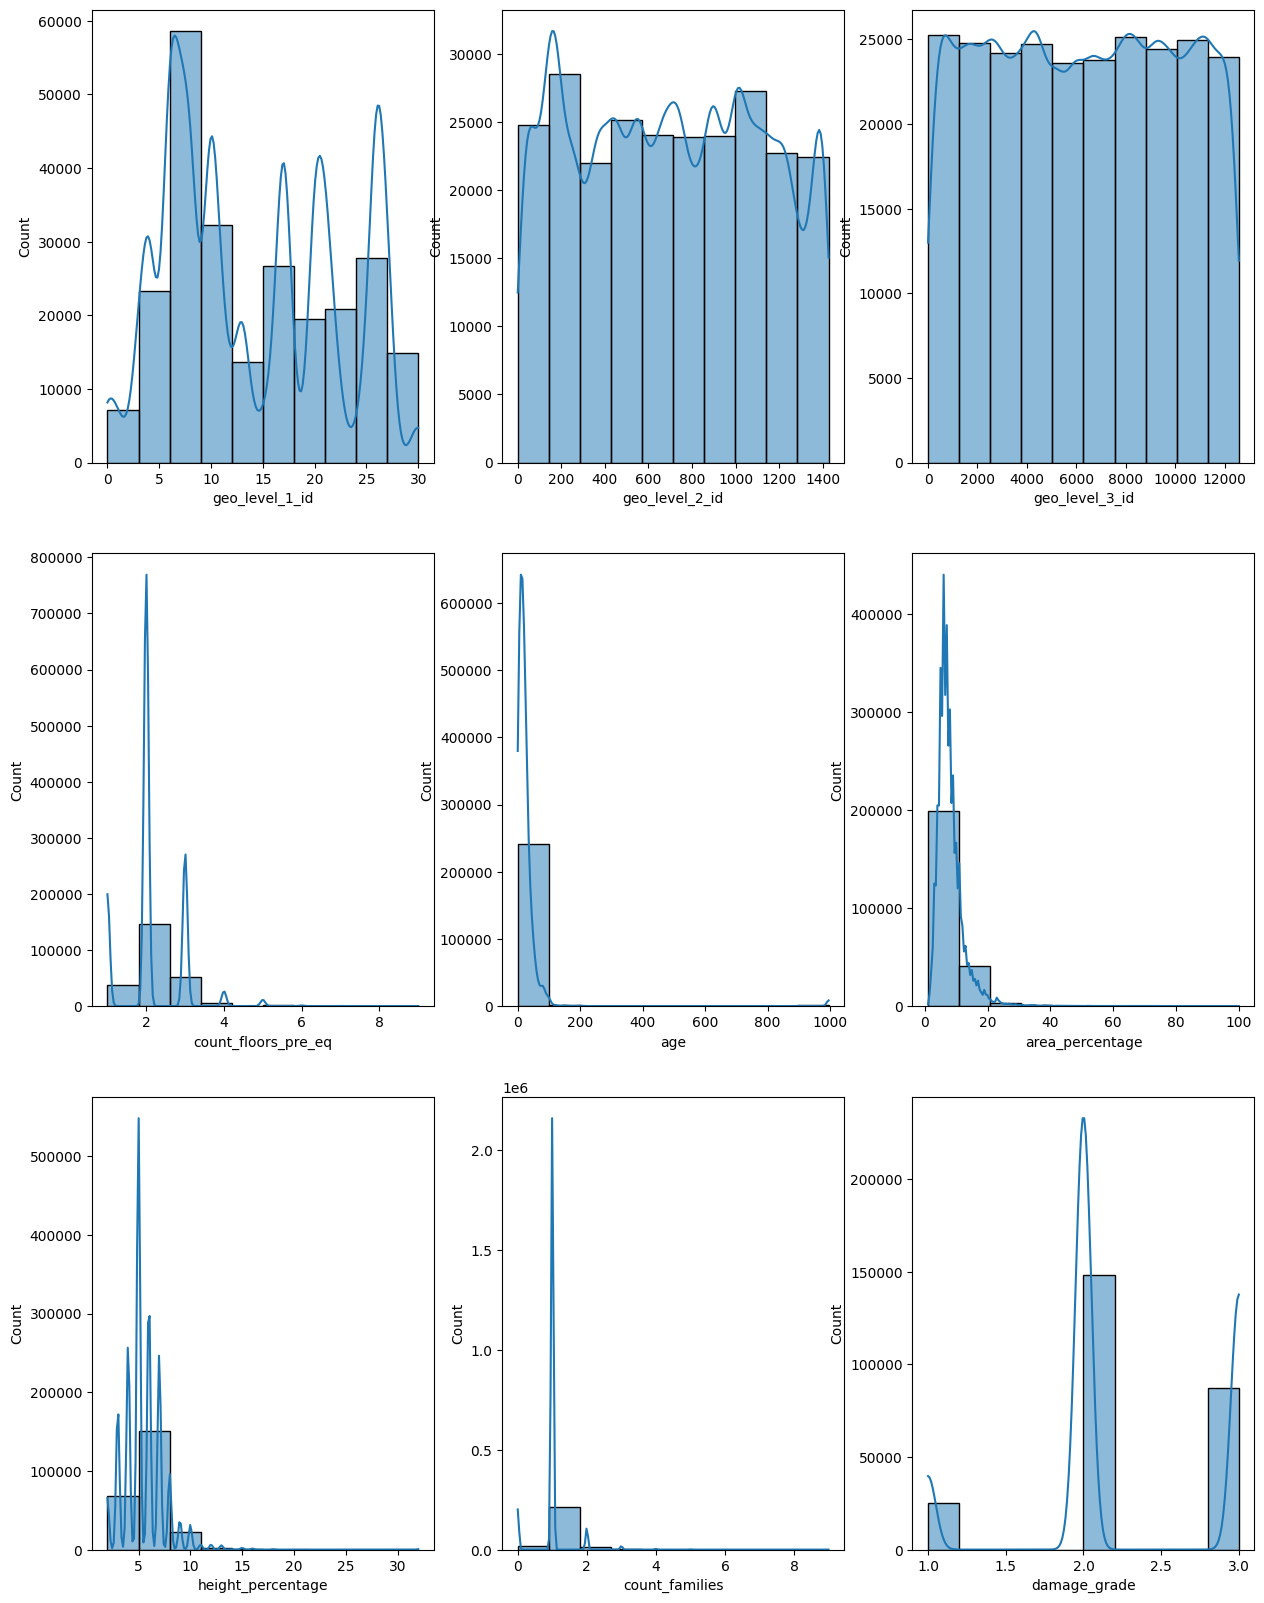

In [ ]:
plt.figure(figsize=(15,20))
pos=1
for i in nonbinary_numcols:
  plt.subplot(3,3,pos)
  sns.histplot(x=data[i],bins=10, kde=True)
  pos = pos+1

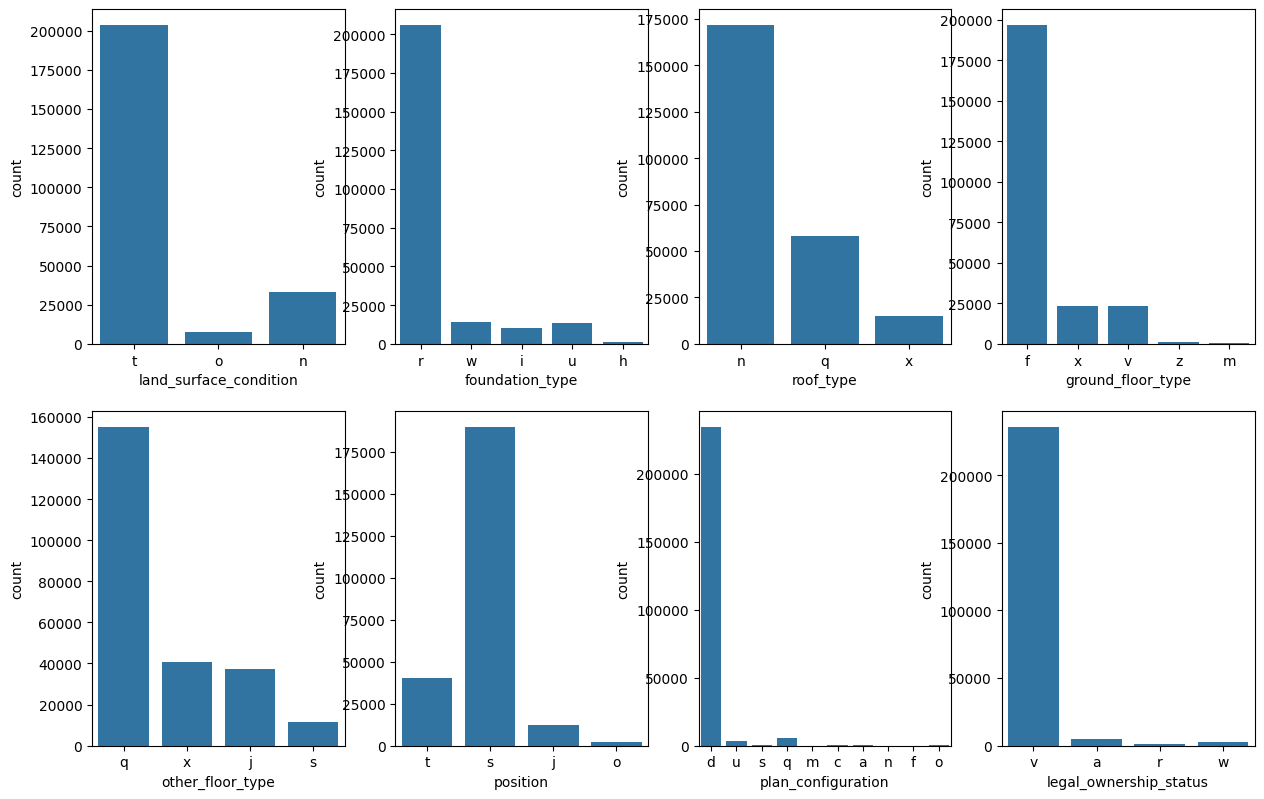

In [ ]:
plt.figure(figsize=(15,20))
pos=1
for i in nonbinary_catcols:
  plt.subplot(4,4,pos)
  sns.countplot(x=data[i])
  pos = pos+1

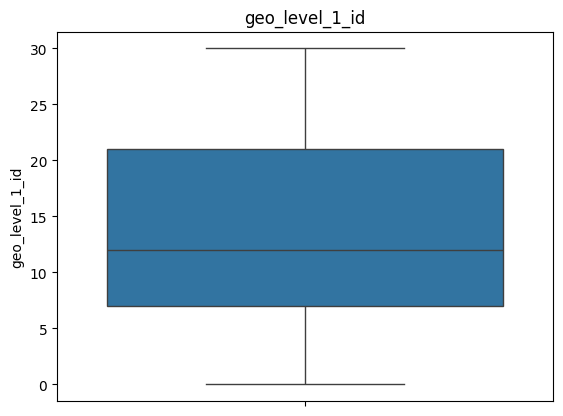

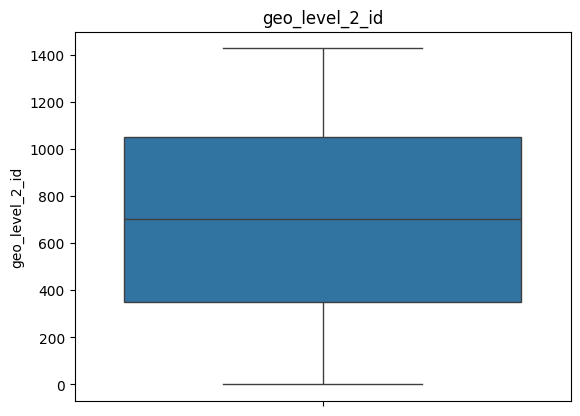

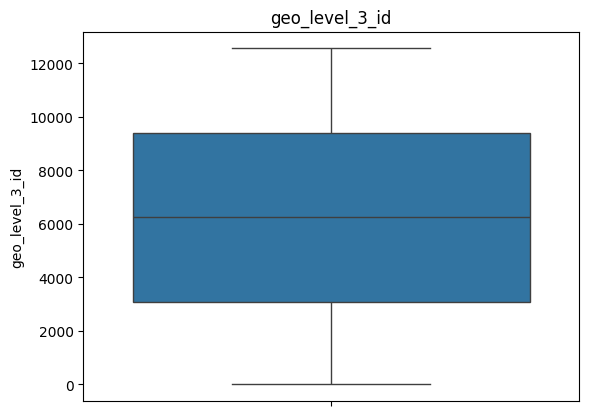

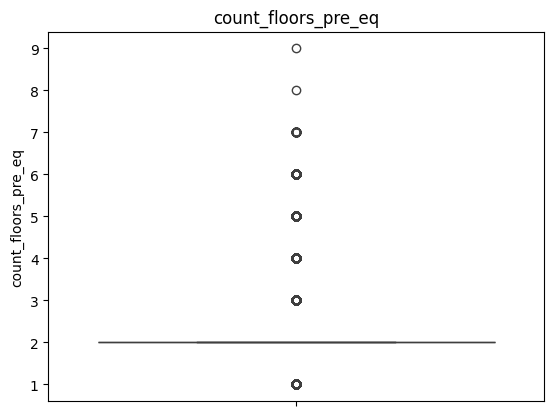

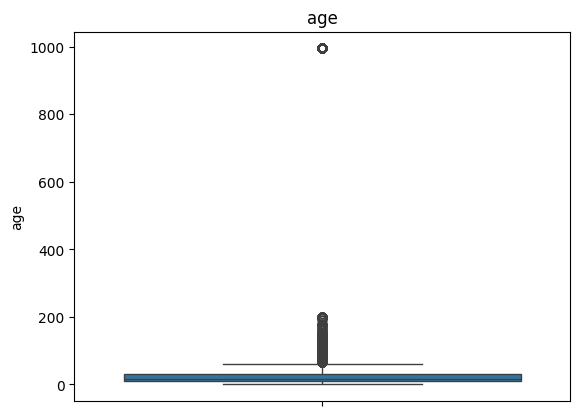

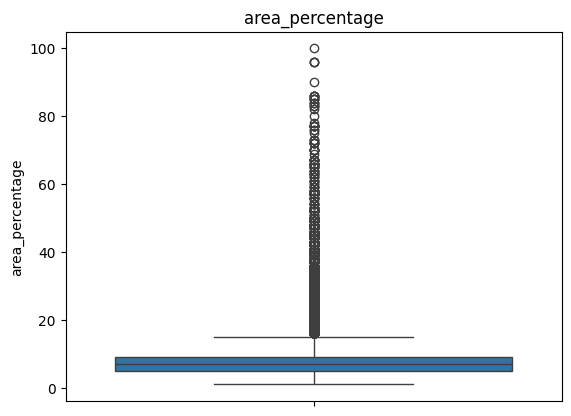

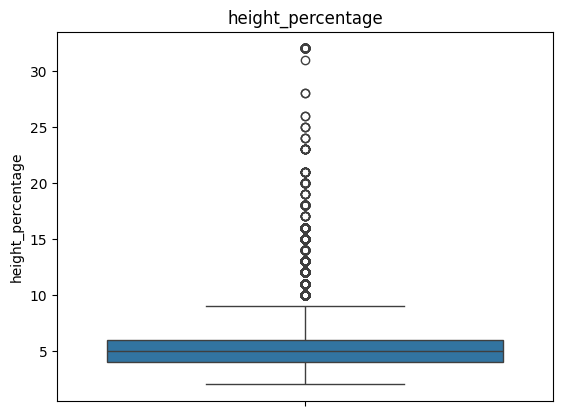

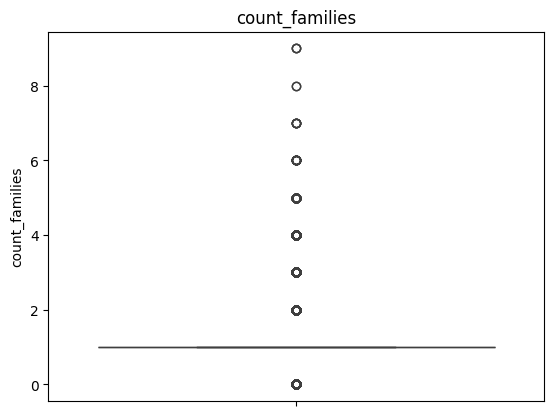

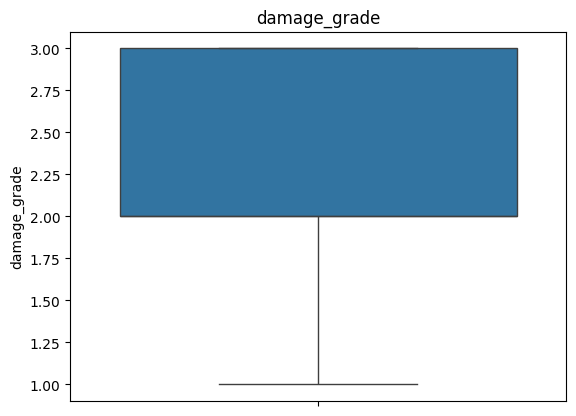

In [ ]:
# Features with Binary class values won't require outlier handling

for i in nonbinary_numcols:
  sns.boxplot(data[i])
  plt.title(i)
  plt.show()

In [ ]:
## Data Preprocessing

In [ ]:
# No missing values
data.isnull().sum().sum()

np.int64(601022)

In [ ]:
# Check duplicates

data.duplicated().sum()

np.int64(26845)

In [ ]:
# Handling duplicates

In [ ]:
# Drop target and checking duplicated

X = data.drop('damage_grade', axis=1)

check1 = data.groupby(list(X.columns))['damage_grade'].nunique()

print("Conflicts BEFORE cleaning:", (check1 > 1).sum())

Conflicts BEFORE cleaning: 3444


In [ ]:
# Same input but different output = problem in data, 3825 conflict groups

In [ ]:
# 3825 GROUPS have same X but different y
# Each group is one unique combination of ALL input features (X)

In [ ]:
data = data.drop_duplicates() #remove duplicates

In [ ]:
# Target need to be cleaned now

In [ ]:
data = data.groupby(list(X))['damage_grade'].agg(lambda x: x.mode()[0]).reset_index()
# Cleaning target based on conflicts and fixing index

In [ ]:
check2 = data.groupby(list(X))['damage_grade'].nunique()

print("Conflicts AFTER cleaning:", (check2 > 1).sum())

Conflicts AFTER cleaning: 0


In [ ]:
data.shape

(230272, 39)

In [ ]:
# Handling outliers

In [ ]:
outlier_cols = []

for col in nonbinary_numcols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    if ((data[col] < LB) | (data[col] > UB)).any():
        outlier_cols.append(col)

print(outlier_cols)

['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'count_families']


In [ ]:
for col in nonbinary_numcols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    data[col] = data[col].clip(LB, UB)

In [ ]:
# Encoding

In [ ]:
cat_cols

['land_surface_condition',
 'foundation_type',
 'roof_type',
 'ground_floor_type',
 'other_floor_type',
 'position',
 'plan_configuration',
 'legal_ownership_status']

In [ ]:
data.sample()

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
119086,13.0,373.0,3746.0,2.0,10.0,5.0,5.0,t,r,n,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


In [ ]:
data = pd.get_dummies(data, columns=cat_cols, drop_first=True).astype(int)  # one-hot encoding applied

In [ ]:
data.sample()

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,...,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w
45671,6,1170,10542,2,10,6,6,0,1,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
data.columns

Index(['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
       'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'count_families', 'has_secondary_use', 'has_secondary_use_agriculture',
       'has_secondary_use_hotel', 'has_secondary_use_rental',
       'has_secondary_use_institution', 'has_secondary_use_school',
       'has_secondary_use_industry', 'has_secondary_use_health_post',
       'has_secondary_use_gov_office', 'has_secondary_use_use_police',
       'has_secondary_use_other', 'damage_grade', 'land_surface_condition_

In [ ]:
data.shape

(230272, 61)

In [ ]:
# Check target data classes with its count

data['damage_grade'].value_counts()

,count
damage_grade,
2,132533
3,74769
1,22970


In [ ]:
## Feature Selection

In [ ]:
res = data.drop('damage_grade', axis=1).corr()
res

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,...,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w
geo_level_1_id,1.000000,-0.062532,0.002329,NaN,-0.053327,0.065128,-0.071890,-0.019466,-0.147215,0.008401,...,0.002003,0.004192,0.001592,0.007451,0.008538,0.009430,0.033145,0.008183,-0.079709,0.004374
geo_level_2_id,-0.062532,1.000000,0.004825,NaN,0.032559,-0.037528,0.037329,0.015103,0.075923,-0.009052,...,-0.000231,-0.008208,0.000616,-0.005327,-0.002067,-0.006903,-0.025897,-0.027552,0.022085,0.013463
geo_level_3_id,0.002329,0.004825,1.000000,NaN,-0.005641,-0.003228,-0.018684,-0.015180,0.027552,0.020532,...,-0.002055,-0.005279,0.002576,-0.002498,0.000159,-0.003856,0.003222,-0.001530,-0.018047,-0.011256
count_floors_pre_eq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,-0.053327,0.032559,-0.005641,NaN,1.000000,-0.032777,0.208400,0.200911,0.062628,0.011442,...,-0.001527,0.013054,-0.002428,-0.001703,-0.016350,-0.006051,-0.018093,-0.004029,0.061463,0.013878
area_percentage,0.065128,-0.037528,-0.003228,NaN,-0.032777,1.000000,0.210126,0.031553,-0.219547,-0.000342,...,0.001826,0.009209,0.001469,0.023740,0.015465,0.020017,0.098079,-0.020725,0.034509,-0.002562
height_percentage,-0.071890,0.037329,-0.018684,NaN,0.208400,0.210126,1.000000,0.162840,-0.072701,-0.020222,...,0.003541,0.010511,0.001844,0.003333,-0.018777,0.000220,0.004111,-0.010753,0.068796,0.002085
has_superstructure_adobe_mud,-0.019466,0.015103,-0.015180,NaN,0.200911,0.031553,0.162840,1.000000,-0.305680,0.007673,...,0.001935,0.005340,-0.001521,-0.004373,0.014013,0.004638,0.018167,0.024620,-0.005022,0.033776
has_superstructure_mud_mortar_stone,-0.147215,0.075923,0.027552,NaN,0.062628,-0.219547,-0.072701,-0.305680,1.000000,-0.034310,...,-0.000114,-0.013720,-0.000153,-0.020804,-0.047502,-0.017518,-0.098654,-0.047458,0.122788,-0.004019
has_superstructure_stone_flag,0.008401,-0.009052,0.020532,NaN,0.011442,-0.000342,-0.020222,0.007673,-0.034310,1.000000,...,-0.001769,-0.000958,-0.000477,0.006465,0.011983,0.003571,-0.009907,-0.005375,0.005566,0.005204


In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [ ]:
res[abs(res) > 0.8]

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w
geo_level_1_id,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geo_level_2_id,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geo_level_3_id,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
count_floors_pre_eq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_percentage,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height_percentage,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_superstructure_adobe_mud,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_superstructure_mud_mortar_stone,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_superstructure_stone_flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 'position_t', 'position_s' has correlation value of above >0.8

# Correlation value - np.float64(-0.8223023933425777)

In [ ]:
# Ignoring this correlation because it is created by OHE, not real data relationship

In [ ]:
X = data.drop('damage_grade', axis=1)
y = data['damage_grade']

In [ ]:
res = X.corr()
res[res>0.8]

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w
geo_level_1_id,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geo_level_2_id,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geo_level_3_id,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
count_floors_pre_eq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_percentage,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height_percentage,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_superstructure_adobe_mud,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_superstructure_mud_mortar_stone,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_superstructure_stone_flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# No 2 input columns is in high correlation of above 0.8

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, train_size=0.80, random_state=42)

In [ ]:
# Data Transformation

In [ ]:
for i in nonbinary_numcols:
  print(i, data[i].skew())

geo_level_1_id 0.2691694232335047
geo_level_2_id 0.03332512366273658
geo_level_3_id -0.00036494965175185284
count_floors_pre_eq 0.0
age 0.9063754861189469
area_percentage 0.947099243637756
height_percentage 0.22052127076142997
count_families 0.0
damage_grade -0.1694109351591388


In [ ]:
# Handling skewness (age, area_percentage are highy skewed)

In [ ]:
# Log Transformation for right skewed data

skew_col = ['age', 'area_percentage']

X_train[skew_col] = np.log1p(X_train[skew_col])
X_test[skew_col] = np.log1p(X_test[skew_col])

In [ ]:
X_train[skew_col].skew()

,0
age,-1.136204
area_percentage,-0.013888


In [ ]:
# Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

In [ ]:
cols = data.drop('damage_grade', axis=1).columns

X_train[cols] = ss.fit_transform(X_train[cols])
X_test[cols] = ss.transform(X_test[cols])

In [ ]:
X_train[cols].head()

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w
181941,0.881714,1.253443,0.373886,0.0,0.105143,-1.308309,-0.813449,-0.314397,0.568815,-0.189547,-0.139692,-0.274109,-0.290662,-0.585999,-0.306186,-0.214555,-0.130978,-0.126401,0.0,2.748582,3.728360,-0.191093,-0.091906,-0.032719,-0.019497,-0.033378,-0.013785,-0.012107,-0.010156,-0.073953,-0.182106,0.454163,-0.210622,0.442145,-0.246683,-0.248239,-0.553962,-0.264686,-0.045704,-0.329412,-0.327393,-0.063508,0.769632,-0.226347,-0.446997,-0.095531,0.548304,-0.451377,-0.037522,0.210284,-0.009607,-0.012762,-0.012973,-0.02521,-0.151513,-0.039364,-0.122739,-0.077576,-5.050351,9.695679
27339,-1.106272,0.363180,-1.568284,0.0,0.702375,-0.428134,-0.215565,-0.314397,0.568815,-0.189547,-0.139692,-0.274109,-0.290662,1.706488,-0.306186,-0.214555,-0.130978,-0.126401,0.0,-0.363824,-0.268214,-0.191093,-0.091906,-0.032719,-0.019497,-0.033378,-0.013785,-0.012107,-0.010156,-0.073953,-0.182106,0.454163,-0.210622,0.442145,-0.246683,-0.248239,-0.553962,-0.264686,-0.045704,-0.329412,-0.327393,-0.063508,0.769632,-0.226347,-0.446997,-0.095531,0.548304,-0.451377,-0.037522,0.210284,-0.009607,-0.012762,-0.012973,-0.02521,-0.151513,-0.039364,-0.122739,-0.077576,0.198006,-0.103139
135650,0.384718,-0.962539,0.973565,0.0,1.313592,0.229276,2.175967,-0.314397,0.568815,-0.189547,-0.139692,-0.274109,-0.290662,-0.585999,-0.306186,-0.214555,-0.130978,-0.126401,0.0,2.748582,-0.268214,5.233044,-0.091906,-0.032719,-0.019497,-0.033378,-0.013785,-0.012107,-0.010156,-0.073953,-0.182106,0.454163,-0.210622,0.442145,-0.246683,-0.248239,1.805177,-0.264686,-0.045704,-0.329412,-0.327393,-0.063508,0.769632,-0.226347,-0.446997,-0.095531,-1.823807,2.215441,-0.037522,0.210284,-0.009607,-0.012762,-0.012973,-0.02521,-0.151513,-0.039364,-0.122739,-0.077576,0.198006,-0.103139
164631,0.757465,0.210770,-1.464087,0.0,0.105143,-1.892028,0.382318,-0.314397,0.568815,-0.189547,-0.139692,-0.274109,-0.290662,1.706488,3.265990,4.660816,-0.130978,-0.126401,0.0,-0.363824,-0.268214,-0.191093,-0.091906,-0.032719,-0.019497,-0.033378,-0.013785,-0.012107,-0.010156,-0.073953,5.491318,-2.201853,-0.210622,0.442145,-0.246683,-0.248239,1.805177,-0.264686,-0.045704,-0.329412,-0.327393,-0.063508,-1.299323,-0.226347,2.237154,-0.095531,0.548304,-0.451377,-0.037522,0.210284,-0.009607,-0.012762,-0.012973,-0.02521,-0.151513,-0.039364,-0.122739,-0.077576,0.198006,-0.103139
12739,-1.354770,1.659868,-0.021238,0.0,1.313592,0.229276,1.578084,3.180697,-1.758042,-0.189547,-0.139692,3.648181,-0.290662,1.706488,3.265990,-0.214555,-0.130978,-0.126401,0.0,-0.363824,-0.268214,-0.191093,-0.091906,-0.032719,-0.019497,-0.033378,-0.013785,-0.012107,-0.010156,-0.073953,-0.182106,0.454163,-0.210622,0.442145,-0.24668

In [ ]:
y_train.value_counts(normalize=True)

,proportion
damage_grade,
2,0.574746
3,0.325193
1,0.100061


In [ ]:
## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [ ]:
lr.fit(X_train, y_train)

lry_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, lry_pred))

              precision    recall  f1-score   support

           1       0.59      0.32      0.42      4537
           2       0.61      0.89      0.72     26655
           3       0.52      0.16      0.24     14863

    accuracy                           0.60     46055
   macro avg       0.57      0.46      0.46     46055
weighted avg       0.58      0.60      0.54     46055



In [ ]:
from sklearn.metrics import f1_score

f1_macro = f1_score(y_test, lry_pred, average='macro')
f1_macro

0.4606441853028967

In [ ]:
# Here, not all classes are learning properly, so moving on with SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
smX_train, smy_train = sm.fit_resample(X_train, y_train)

In [ ]:
lr.fit(smX_train, smy_train)

smy_pred = lr.predict(X_test)

In [ ]:
print(classification_report(y_test, smy_pred))

              precision    recall  f1-score   support

           1       0.37      0.69      0.48      4537
           2       0.68      0.35      0.46     26655
           3       0.43      0.69      0.53     14863

    accuracy                           0.50     46055
   macro avg       0.50      0.58      0.49     46055
weighted avg       0.57      0.50      0.49     46055



In [ ]:
f1_macro = f1_score(y_test, smy_pred, average='macro')
f1_macro

0.49294518575024115

In [ ]:
## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(smX_train, smy_train)

dty_pred = dt.predict(X_test)
print(classification_report(y_test, dty_pred))

              precision    recall  f1-score   support

           1       0.45      0.48      0.46      4838
           2       0.71      0.69      0.70     28176
           3       0.59      0.62      0.60     15868

    accuracy                           0.64     48882
   macro avg       0.58      0.60      0.59     48882
weighted avg       0.65      0.64      0.64     48882



In [ ]:
f1_macro = f1_score(y_test, dty_pred, average='macro')
f1_macro

0.588868857499798

In [ ]:
## Decision Tree Hyperparameter Tuning (GridSearchCV)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=param_dt,
    cv=5,
    scoring='f1_macro',  #treat all classes equally in target
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(smX_train, smy_train)

print(dt_grid.best_params_)

dtcvy_pred = dt_grid.best_estimator_.predict(X_test)
print(classification_report(y_test, dtcvy_pred))

Fitting 5 folds for each of 160 candidates, totalling 800 fits
{'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
              precision    recall  f1-score   support

           1       0.48      0.56      0.52      4838
           2       0.73      0.70      0.72     28176
           3       0.63      0.65      0.64     15868

    accuracy                           0.67     48882
   macro avg       0.62      0.64      0.63     48882
weighted avg       0.68      0.67      0.67     48882



In [ ]:
f1_macro = f1_score(y_test, dtcvy_pred, average='macro')
f1_macro

0.6257688363374554

In [ ]:
## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(smX_train, smy_train)

rfy_pred = rf.predict(X_test)
print(classification_report(y_test, rfy_pred))

              precision    recall  f1-score   support

           1       0.56      0.55      0.56      4838
           2       0.73      0.78      0.76     28176
           3       0.68      0.61      0.64     15868

    accuracy                           0.70     48882
   macro avg       0.66      0.65      0.65     48882
weighted avg       0.70      0.70      0.70     48882



In [ ]:
f1_macro = f1_score(y_test, rfy_pred, average='macro')
f1_macro

0.6527374840527292

In [ ]:
## Random Forest with Hyperparameter Tuning (GridSearchCV)

In [ ]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_rf,
    cv=3,
    n_jobs=1,
    verbose=2,
    scoring='f1_macro'
)

rf_grid.fit(smX_train, smy_train)

print(rf_grid.best_params_)

rfcvy_pred = rf_grid.best_estimator_.predict(X_test)
print(classification_report(y_test, rfcvy_pred))

Fitting 3 folds for each of 72 candidates, totalling 216 fits
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.3min
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.2min
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.2min
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 2.5min
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 2.4min
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 2.3min
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 1.2min
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total

In [ ]:
f1_macro = f1_score(y_test, rfcvy_pred, average='macro')
f1_macro

0.6477794618892854

In [ ]:
## Gradiant Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(smX_train, smy_train)

gby_pred = gb.predict(X_test)
print(classification_report(y_test, gby_pred))

              precision    recall  f1-score   support

           1       0.48      0.58      0.52      4838
           2       0.71      0.69      0.70     28176
           3       0.62      0.61      0.62     15868

    accuracy                           0.65     48882
   macro avg       0.60      0.63      0.61     48882
weighted avg       0.66      0.65      0.66     48882



In [ ]:
f1_macro = f1_score(y_test, gby_pred, average='macro')
f1_macro

0.6138104957300374

In [ ]:
## Gradiant Boosting with Hyperparameter Tuning (GridSearchCV)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

gb = GradientBoostingClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

gb_grid = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_grid,
    cv=3,
    scoring='f1_macro',   #for imbalance
    verbose=2,
    n_jobs=-1
)

gb_grid.fit(smX_train, smy_train)

print("Best Params:", gb_grid.best_params_)

gbcvy_pred = gb_grid.best_estimator_.predict(X_test)

print(classification_report(y_test, gbcvy_pred))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 5, 'learning_rate': 0.1}
              precision    recall  f1-score   support

           1       0.54      0.53      0.53      4838
           2       0.71      0.76      0.74     28176
           3       0.66      0.59      0.62     15868

    accuracy                           0.68     48882
   macro avg       0.64      0.62      0.63     48882
weighted avg       0.68      0.68      0.68     48882



In [ ]:
f1_macro = f1_score(y_test, gbcvy_pred, average='macro')
f1_macro

0.6295893809283296

In [ ]:
## XG Boost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)

smy_train_adj = smy_train - 1  #xgboost expect classes like 0,1,2..

xgb.fit(smX_train, smy_train_adj)

xgby_pred = xgb.predict(X_test)
xgby_pred = xgby_pred+1
print(classification_report(y_test, xgby_pred))

              precision    recall  f1-score   support

           1       0.61      0.51      0.56      4838
           2       0.73      0.81      0.77     28176
           3       0.71      0.60      0.65     15868

    accuracy                           0.71     48882
   macro avg       0.68      0.64      0.66     48882
weighted avg       0.71      0.71      0.71     48882



In [ ]:
f1_macro = f1_score(y_test, xgby_pred, average='macro')
f1_macro

0.6568344703828454

In [ ]:
## XG Boost with Hyperparameter Tuning (GridSearchCV)

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

smy_train_adj = smy_train - 1  #(0-based indexing)
y_test_adj = y_test - 1

xgb = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42
)

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    verbose=2,
    n_jobs=-1
)

grid.fit(smX_train, smy_train_adj)

print("Best Parameters:", grid.best_params_)

xgbcvy_pred = grid.best_estimator_.predict(X_test)

#xgbcvy_pred = xgby_pred + 1  #Convert back to original labels

print(classification_report(y_test_adj, xgbcvy_pred))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
              precision    recall  f1-score   support

           0       0.63      0.51      0.56      4537
           1       0.73      0.81      0.77     26655
           2       0.70      0.59      0.64     14863

    accuracy                           0.71     46055
   macro avg       0.69      0.64      0.66     46055
weighted avg       0.71      0.71      0.71     46055



In [ ]:
f1_macro = f1_score(y_test_adj, xgbcvy_pred, average='macro')
f1_macro

0.6596084971054165

In [ ]:
## Model Comparison

In [ ]:
model = ['Logistic Regression', 'Decision Tree', 'DecisionTree6Hyperparameter', 'Random Forest', 'Random ForestHyperparameter', 'Gradiant Boosting', 'Gradiant Boosting-Hyperparameter', 'XG Boost', 'XG Boost-Hyperparameter']
f1_macro = [0.49, 0.58, 0.62, 0.65, 0.64, 0.61, 0.62, 0.65, 0.66]

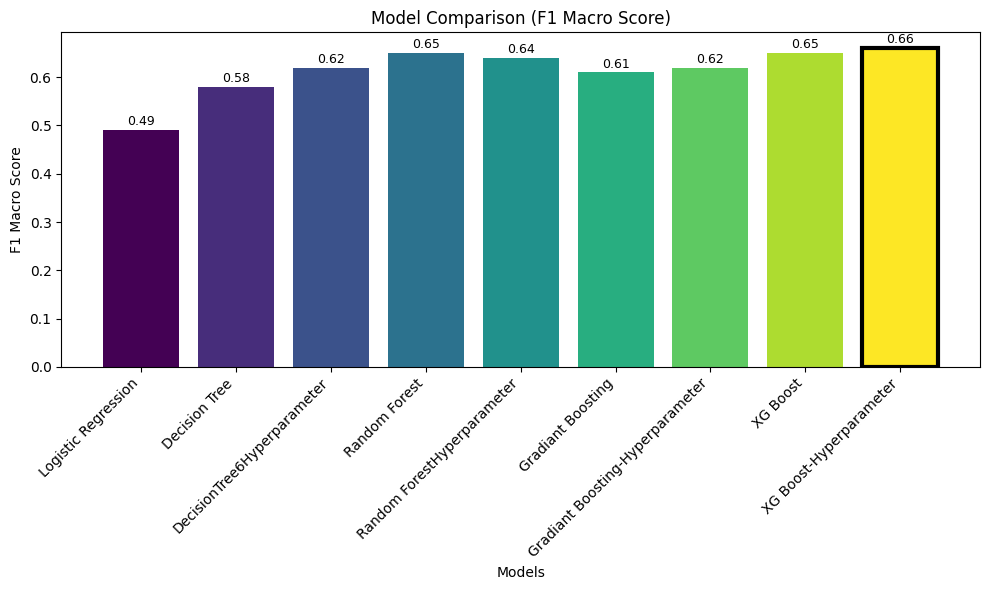

In [ ]:
colors = plt.cm.viridis(np.linspace(0, 1, len(model)))

plt.figure(figsize=(10,6))

bars = plt.bar(model, f1_macro, color=colors)

# Highlight best model
best_idx = np.argmax(f1_macro)
bars[best_idx].set_edgecolor('black')
bars[best_idx].set_linewidth(3)

# Add value labels on top
for i, v in enumerate(f1_macro):
    plt.text(i, v + 0.01, str(v), ha='center', fontsize=9)

# Labels and title
plt.xlabel("Models")
plt.ylabel("F1 Macro Score")
plt.title("Model Comparison (F1 Macro Score)")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

The tuned XGBoost model achieved 71% accuracy and 0.66 macro F1-score, demonstrating strong performance in predicting the earthquake damage levels.

                                   Feature  Importance
33                       foundation_type_r    0.384137
39                     ground_floor_type_v    0.066986
8      has_superstructure_mud_mortar_stone    0.049947
4                                      age    0.044395
0                           geo_level_1_id    0.040163
5                          area_percentage    0.029610
42                      other_floor_type_q    0.028017
12  has_superstructure_cement_mortar_brick    0.026424
9            has_superstructure_stone_flag    0.024353
6                        height_percentage    0.021101


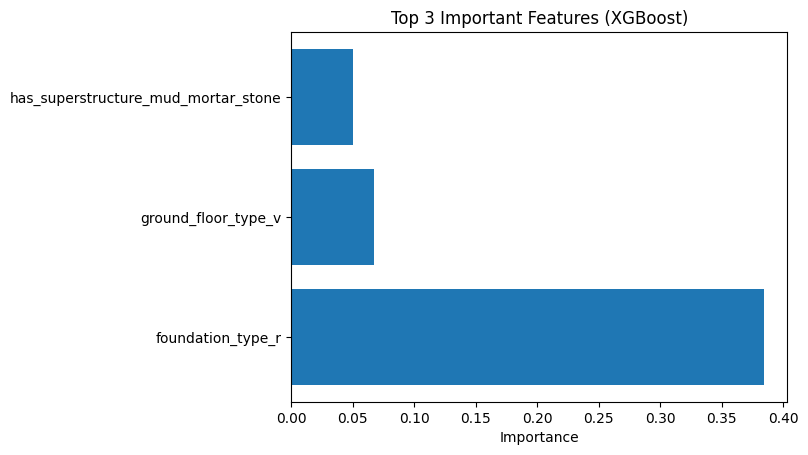

In [ ]:
# Get best model from GridSearch
model = grid.best_estimator_

# Create feature importance dataframe
feat_imp = pd.DataFrame({
    'Feature': smX_train.columns,   # use smX_train (since you trained on it)
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Show top 10 features
print(feat_imp.head(10))

# Pick top 3
top3 = feat_imp.head(3)

# Plot
plt.barh(top3['Feature'], top3['Importance'])
plt.xlabel("Importance")
plt.title("Top 3 Important Features (XGBoost)")
plt.show()

**Suggestions to Seismologists:**


*   Foundation type has the highest impact on damage severity. So, Recommend stronger, earthquake-resistant foundation designs, especially in high-risk zones
*   Ground floor type significantly affects structural stability. Ensure proper ground floor design standards to improve load distribution during earthquakes.


*   Buildings made with mud mortar and stone show higher damage. Better to use reinforced materials (e.g., concrete, steel) instead of traditional weak materials.



